# Investigations into the Grain Form of the Layer Above the Layer of Concern or Failure


### Grain Form of Layer Above the Layer of Concern in Pits Dug on Avalanche Crowns and Flanks

**Follow up question from Karl:**
- For all of the avalanches where the LOC is depth hoar, what crystal type is the layer immediately above the LOC? In other words, what percentage of those layers above the LOC are new snow, small facets, depth hoar, etc.?

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from snowpyt_mechparams.snowpilot import parse_caaml_directory

In [20]:
# Parse all CAAML files in *data_dir* and return a list of Pit objects.
all_pits = parse_caaml_directory('data')

print(f'Loaded {len(all_pits):,} snow pits')

Loaded 50,278 snow pits


**For pits dug on avalanche crowns and flanks, what is the grain form of the layer of concern?**
- What is the distribution of grain forms
- How often is the grain for Depth Hoar (DH)? 

In [21]:
# Filter to pits dug on avalanche crowns and flanks
crown_and_flank_pits = []

for pit in all_pits:
    if pit.core_info.location.pit_near_avalanche_location == 'crown' or pit.core_info.location.pit_near_avalanche_location == 'flank':
        crown_and_flank_pits.append(pit)

print(f'Pits on avalanche crown or flank: {len(crown_and_flank_pits)}')

Pits on avalanche crown or flank: 1194


In [22]:
# Filter to pits where the layer of concern is depth hoar
crown_and_flank_pits_dh = []

for pit in crown_and_flank_pits:
    loc = pit.snow_profile.layer_of_concern # layer of concern
    gfp = getattr(loc, "grain_form_primary", None) if loc is not None else None # get primary grain form of LOC
    if gfp and gfp.basic_grain_class_code == 'DH':
        crown_and_flank_pits_dh.append(pit)

print(f'Pits with DH LOC: {len(crown_and_flank_pits_dh)}')


Pits with DH LOC: 82


In [23]:
# Extract grain form of layer above layer of concern

grain_form_above_dh = []

for pit in crown_and_flank_pits_dh:

    # Pit info
    pit_id = pit.core_info.pit_id
    pit_near_avalanche_location = pit.core_info.location.pit_near_avalanche_location

    # Get index of layer of concern
    loc_idx = None
    for i, layer in enumerate(pit.snow_profile.layers):
        if layer.layer_of_concern:
            loc_idx = i # index of layer of concern
            break
    if loc_idx is None or loc_idx == 0:
        grain_form_above_dh[pit.core_info.pit_id] = None
        continue

    above = pit.snow_profile.layers[loc_idx - 1] # layer above LOC
    gfp = getattr(above, "grain_form_primary", None) # grain form of layer above LOC

    # Record pit and grain form of layer above LOC
    info = {
        'pit_id': pit_id,
        'pit_near_avalanche_location': pit_near_avalanche_location,
        'grain_form_above_loc': gfp.basic_grain_class_code if gfp is not None else None
    }
    grain_form_above_dh.append(info)


grain_form_above_dh_df = pd.DataFrame(grain_form_above_dh)

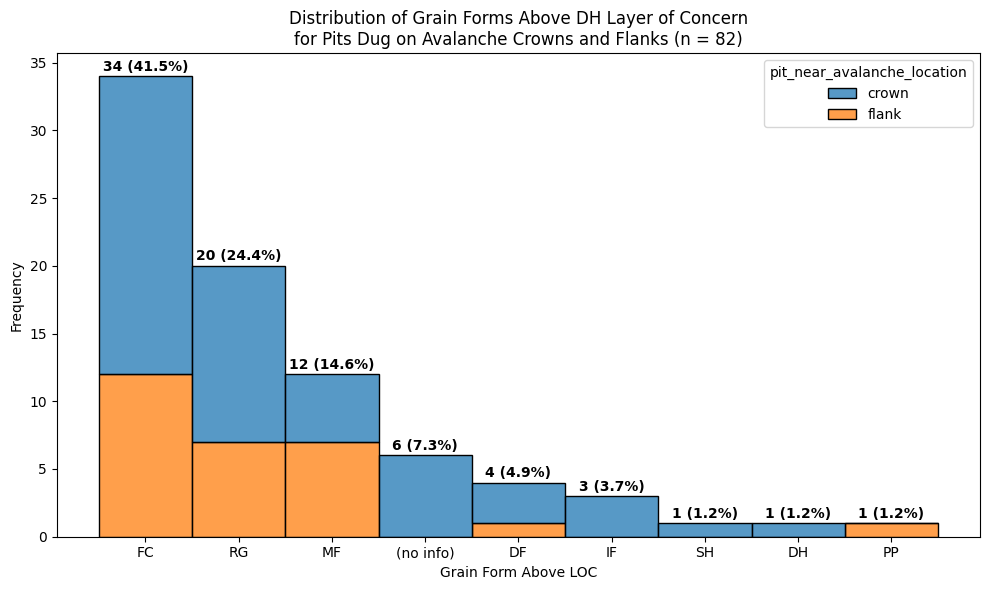

In [24]:
# Plot the frequency of grain forms above DH LOC, stacked by crown/flank
_plot_df = grain_form_above_dh_df.copy()
_plot_df['grain_form_above_loc'] = _plot_df['grain_form_above_loc'].fillna('(no info)')
gf_order = _plot_df['grain_form_above_loc'].value_counts().index.tolist()
_plot_df['grain_form_above_loc'] = pd.Categorical(
    _plot_df['grain_form_above_loc'], categories=gf_order, ordered=True
)
hue_order = sorted(_plot_df['pit_near_avalanche_location'].dropna().unique())

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=_plot_df,
    x='grain_form_above_loc',
    hue='pit_near_avalanche_location',
    hue_order=hue_order,
    multiple='stack',
    ax=ax,
)

bar_totals = _plot_df.groupby('grain_form_above_loc', observed=False).size().reindex(
    gf_order, fill_value=0
)
total_count = len(_plot_df)
for i, gf in enumerate(gf_order):
    total = int(bar_totals.loc[gf])
    if total <= 0:
        continue
    pct = 100 * total / total_count if total_count else 0
    ax.annotate(
        f'{total} ({pct:.1f}%)',
        xy=(i, total),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold',
    )

ax.set_title(
    'Distribution of Grain Forms Above DH Layer of Concern\nfor Pits Dug on Avalanche Crowns and Flanks (n = %d)'
    % len(grain_form_above_dh_df)
)
ax.set_xlabel('Grain Form Above LOC')
ax.set_ylabel('Frequency')
fig.tight_layout()
plt.show()

### ECT: Grain Form of Layer Above the Layer of Failure for ECTP results

- For all ECTs where the LOC is depth hoar, and that propagate completely across the column (ECTPs), what crystal type is the layer immediately above the LOC?

In [ ]:
ECTP_results = []

### PST:

- For all PSTs where the LOC is depth hoar, and that propagate to END with a cut length less than 30 cm, what crystal type is the layer immediately above the LOC? 